In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Normalization, InputLayer

In [2]:
# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
class DeepModel(Model):
    def __init__(self, units=64, activation='relu'):
        super().__init__()
        self.norm = Normalization()
        self.norm.adapt(X_train)

        self.hidden1 = Dense(units, activation=activation)
        self.hidden2 = Dense(units, activation=activation)

        self.out = Dense(1)

    def call(self, X):
        X = self.norm(X)
        X = self.hidden1(X)
        X = self.hidden2(X)
        return self.out(X)

In [4]:
model = DeepModel(units=64, activation='relu')

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9033 - mae: 0.6442 - val_loss: 0.4898 - val_mae: 0.4870
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4732 - mae: 0.4521 - val_loss: 0.4617 - val_mae: 0.4670
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3724 - mae: 0.4292 - val_loss: 0.4159 - val_mae: 0.4717
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3686 - mae: 0.4227 - val_loss: 0.3892 - val_mae: 0.4298
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3350 - mae: 0.4097 - val_loss: 0.3688 - val_mae: 0.4173
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3395 - mae: 0.4051 - val_loss: 0.3516 - val_mae: 0.4160
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3144 - mae: 0.3915 - val_loss: 0.3405 - val_mae: 0.4091
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3099 - mae: 0.3890 - val_loss: 0.3768 - val_mae: 0.3964
Epoch 9/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [5]:
model.evaluate(X_test, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3113 - mae: 0.3878


[0.3113044202327728, 0.3877856731414795]

In [6]:
model.predict(X_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[0.524625 ],
       [1.2674143],
       [4.2980056],
       [2.552691 ],
       [2.8685894]], dtype=float32)

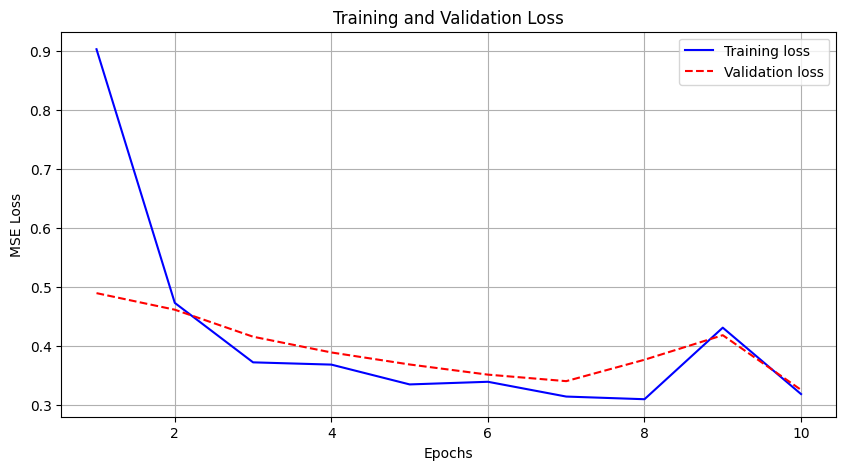

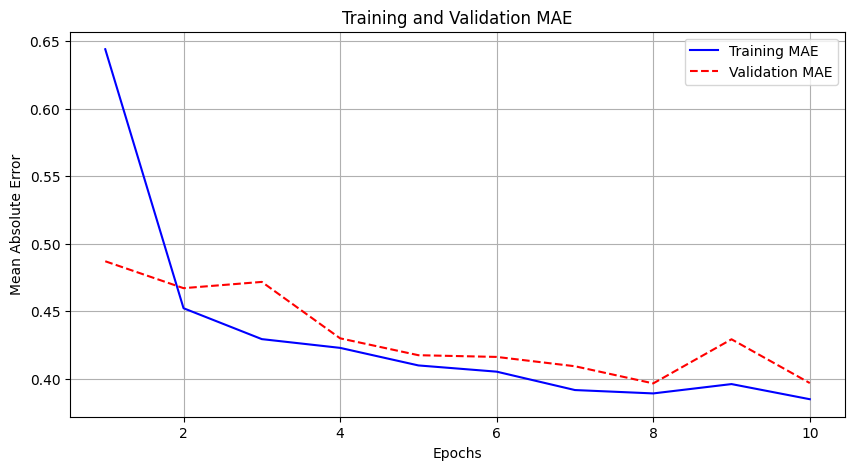

In [18]:
import matplotlib.pyplot as plt

# Get history data
history_dict = history.history

# Extract loss and mae
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mae = history_dict['mae']
val_mae = history_dict['val_mae']

epochs = range(1, len(loss) + 1)

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'b-', label='Training loss')
plt.plot(epochs, val_loss, 'r--', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(10, 5))
plt.plot(epochs, mae, 'b-', label='Training MAE')
plt.plot(epochs, val_mae, 'r--', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
class DeepWideModel(Model):
    def __init__(self, units=64, activation='relu'):
        super().__init__()

        # Wide and Deep Normalization layers
        self.norm_wide = Normalization()
        self.norm_deep = Normalization()
        
        # Adapt each Normalization layer on its corresponding feature slice
        # so their internal mean/var shapes match the slices used in `call()`
        self.norm_wide.adapt(X_train[:, :5])
        self.norm_deep.adapt(X_train[:, 5:])

        self.hidden1 = Dense(units, activation=activation)
        self.hidden2 = Dense(units, activation=activation)

        self.out = Dense(1, activation='linear')

    def call(self, X):
        X_wide = X[:, :5]  # First half for wide
        X_deep = X[:, 5:]  # Second half for deep

        X_wide = self.norm_wide(X_wide)
        X_deep = self.norm_deep(X_deep)

        # Deep branch
        X_deep = self.hidden1(X_deep)
        X_deep = self.hidden2(X_deep)

        # Combine wide + deep
        X_concat = tf.concat([X_wide, X_deep], axis=1)

        return self.out(X_concat)

In [12]:
X.shape

(20640, 8)

In [16]:
deep_wide_model = DeepWideModel(units=64, activation='relu')

deep_wide_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_dw = deep_wide_model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4750 - mae: 0.8402 - val_loss: 0.8065 - val_mae: 0.6628
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4750 - mae: 0.8402 - val_loss: 0.8065 - val_mae: 0.6628
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5897 - mae: 0.5591 - val_loss: 0.5072 - val_mae: 0.5193
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5897 - mae: 0.5591 - val_loss: 0.5072 - val_mae: 0.5193
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4284 - mae: 0.4717 - val_loss: 0.4139 - val_mae: 0.4641
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4284 - mae: 0.4717 - val_loss: 0.4139 - val_mae: 0.4641
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3868 - mae: 0.4454 - val_loss: 0.4479 - val_mae: 0.4841
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3868 - mae: 0.4454 - val_loss: 0.4479 - val_mae: 0.4841
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

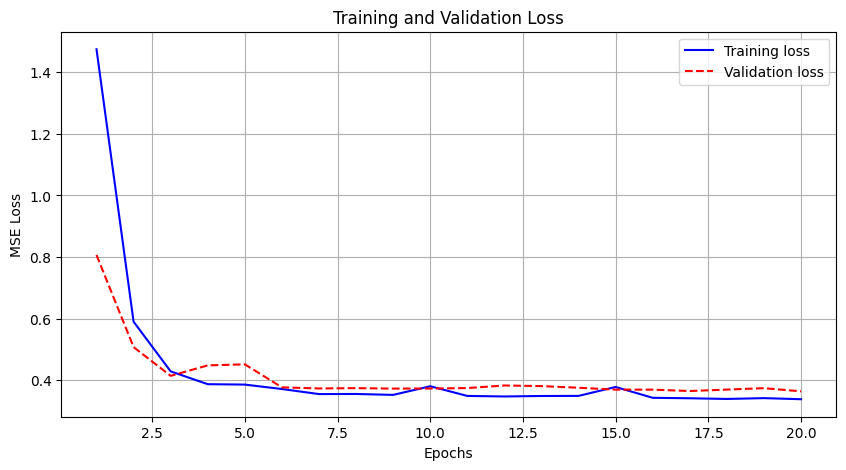

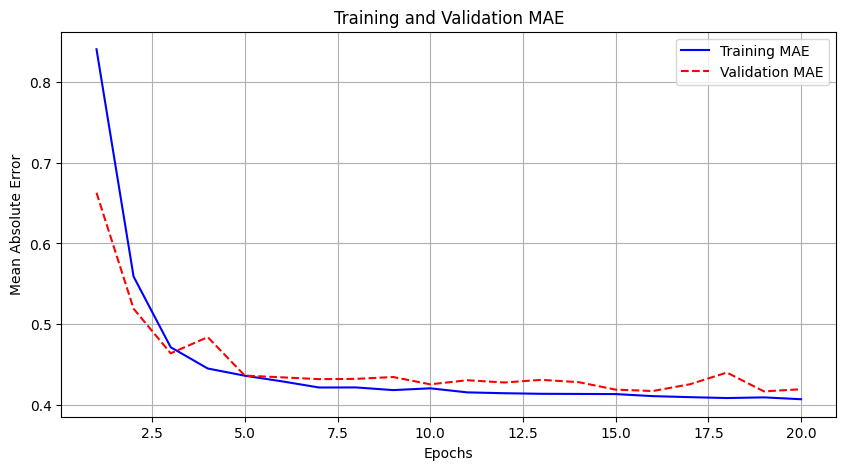

In [17]:
import matplotlib.pyplot as plt

# Get history data
history_dict = history_dw.history

# Extract loss and mae
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mae = history_dict['mae']
val_mae = history_dict['val_mae']

epochs = range(1, len(loss) + 1)

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'b-', label='Training loss')
plt.plot(epochs, val_loss, 'r--', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(10, 5))
plt.plot(epochs, mae, 'b-', label='Training MAE')
plt.plot(epochs, val_mae, 'r--', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
deep_wide_model.evaluate(X_test, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3473 - mae: 0.4097
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3473 - mae: 0.4097


[0.3472731411457062, 0.4096851944923401]

In [20]:
from sklearn.metrics import r2_score

y_pred_deep = model.predict(X_test)
y_pred_deep_wide = deep_wide_model.predict(X_test)

r2 = r2_score(y_test, y_pred_deep)
r2_wide = r2_score(y_test, y_pred_deep_wide)

print(f"R^2 score (Deep Model): {r2:.4f}")
print(f"R^2 score (Deep & Wide Model): {r2_wide:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R^2 score (Deep Model): 0.7624
R^2 score (Deep & Wide Model): 0.7350
R^2 score (Deep Model): 0.7624
R^2 score (Deep & Wide Model): 0.7350


In [21]:
deep_wide_model.save("models/deep_wide_model.keras")
model.save("models/deep_model.keras")